# Multicollinearity and model selection

When predictors are strongly correlated with each other, the model cannot tell their effects apart: coefficients become unstable, their standard errors explode and individual tests lose power. This is **multicollinearity**.

A standard way to measure it is the **variance inflation factor** of predictor $j$,

$$\mathrm{VIF}_j = \frac{1}{1 - R_j^2},$$

where $R_j^2$ is the $R^2$ obtained by regressing $x_j$ on all the other predictors. A VIF of 1 means $x_j$ is uncorrelated with the others; values above 5–10 are usually considered critical.

Multicollinearity is closely tied to **model selection**: which predictors should the final model contain? This notebook works through three datasets, each calling for a different remedy:

1. **Fitness**: two almost redundant measurements; drop one, or combine them into a new variable.
2. **Hospital length of stay**: several variables measuring the same thing (hospital size); build ratios, then use stepwise selection.
3. **Fund of hedge funds**: collinearity that cannot be engineered away; let variable selection reveal the actual portfolio.

Stepwise selection uses `forward_selection` and `backward_selection` from `diagnostics.py`, which add or remove one formula term at a time as long as an information criterion (AIC or BIC) improves.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

from diagnostics import backward_selection, diagnostic_plots, forward_selection, vif_table

warnings.filterwarnings("ignore", message="kurtosistest only valid")
plt.rcParams["figure.dpi"] = 100

## 1. Fitness: predicting oxygen uptake

Measuring the oxygen uptake during exercise (`oxy`, in ml per kg per minute) is the gold standard for aerobic fitness, but it requires a lab. Can we predict it from simple measurements of 31 people?

- `age`, `weight` (kg);
- `runtime`: time to run 1.5 miles (minutes);
- `rstpulse`, `runpulse`, `maxpulse`: heart rate at rest, at the end of the run, and maximum during the run.

In [2]:
fitness = pd.read_csv("data/fitness.csv")
predictors = ["age", "weight", "runtime", "rstpulse", "runpulse", "maxpulse"]
full = smf.ols("oxy ~ " + " + ".join(predictors), data=fitness).fit()
print(full.summary().tables[1])
print(f"R-squared: {full.rsquared:.3f}   global F-test p-value: {full.f_pvalue:.1e}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    102.9345     12.403      8.299      0.000      77.335     128.534
age           -0.2270      0.100     -2.273      0.032      -0.433      -0.021
weight        -0.0742      0.055     -1.359      0.187      -0.187       0.038
runtime       -2.6287      0.385     -6.835      0.000      -3.422      -1.835
rstpulse      -0.0215      0.066     -0.326      0.747      -0.158       0.115
runpulse      -0.3696      0.120     -3.084      0.005      -0.617      -0.122
maxpulse       0.3032      0.136      2.221      0.036       0.022       0.585
R-squared: 0.849   global F-test p-value: 9.7e-09


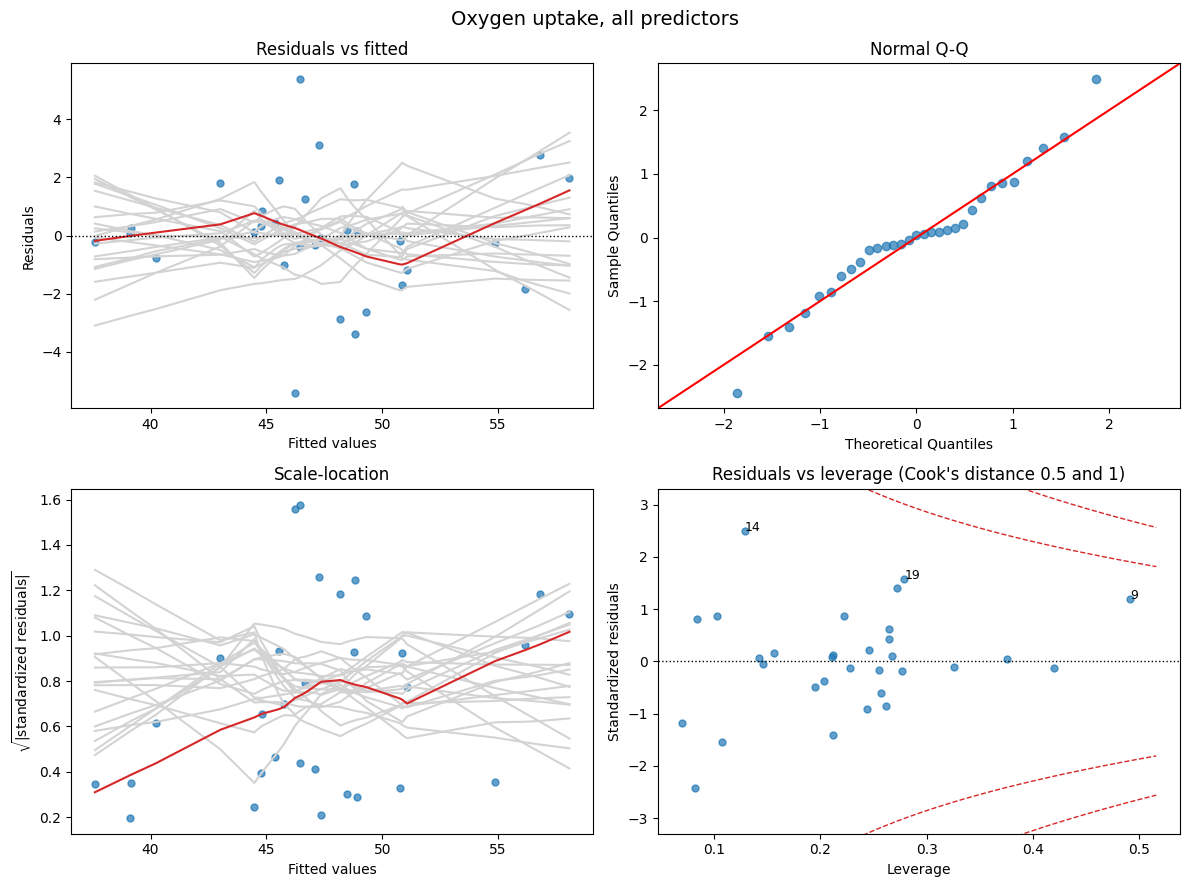

In [3]:
diagnostic_plots(full, title="Oxygen uptake, all predictors")

The global F-test is highly significant and $R^2 \approx 0.85$: the predictors explain oxygen uptake well. The residual plots are acceptable: two observations have relatively large residuals (one positive, one negative), and the variance is at the limit of being constant, but none of the points is influential.

Next we look at how the predictors relate to each other:

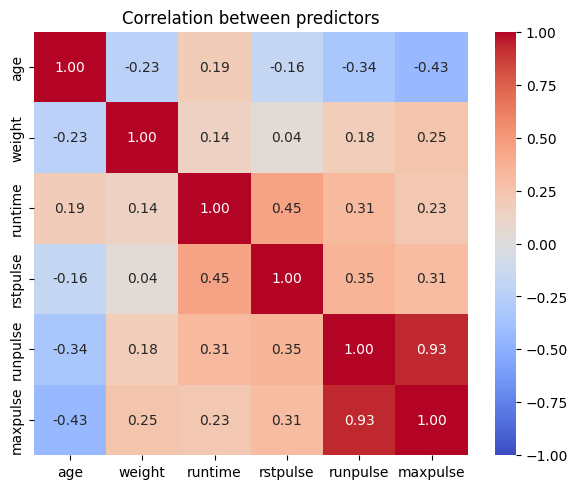

age         1.51
weight      1.16
runtime     1.59
rstpulse    1.42
runpulse    8.44
maxpulse    8.74
Name: VIF, dtype: float64

In [4]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(fitness[predictors].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between predictors")
plt.show()
vif_table(fitness[predictors])

`runpulse` and `maxpulse` are strongly correlated (r = 0.93) and have VIFs above 8, while all other predictors are close to 1. The two pulses carry almost the same information: someone with a high heart rate at the end of the run also has a high maximum heart rate.

There are two standard remedies.

**Remedy 1: drop one of the two.** `maxpulse` is the natural candidate: measuring it requires monitoring the whole run, while `runpulse` is taken at the end.

In [5]:
dropped = smf.ols("oxy ~ age + weight + runtime + rstpulse + runpulse", data=fitness).fit()
print(vif_table(fitness[["age", "weight", "runtime", "rstpulse", "runpulse"]]).to_dict())
print(f"R-squared: {dropped.rsquared:.3f}")

{'age': 1.41, 'weight': 1.12, 'runtime': 1.58, 'rstpulse': 1.41, 'runpulse': 1.39}
R-squared: 0.818


**Remedy 2: combine them into a new, more meaningful variable.** The ratio `runpulse / maxpulse` measures the *intensity* of the effort at the end of the run, relative to the person's maximum. It keeps information from both pulses without the redundancy.

{'age': 1.23, 'weight': 1.13, 'runtime': 1.54, 'rstpulse': 1.39, 'intensity': 1.14}
R-squared: 0.839


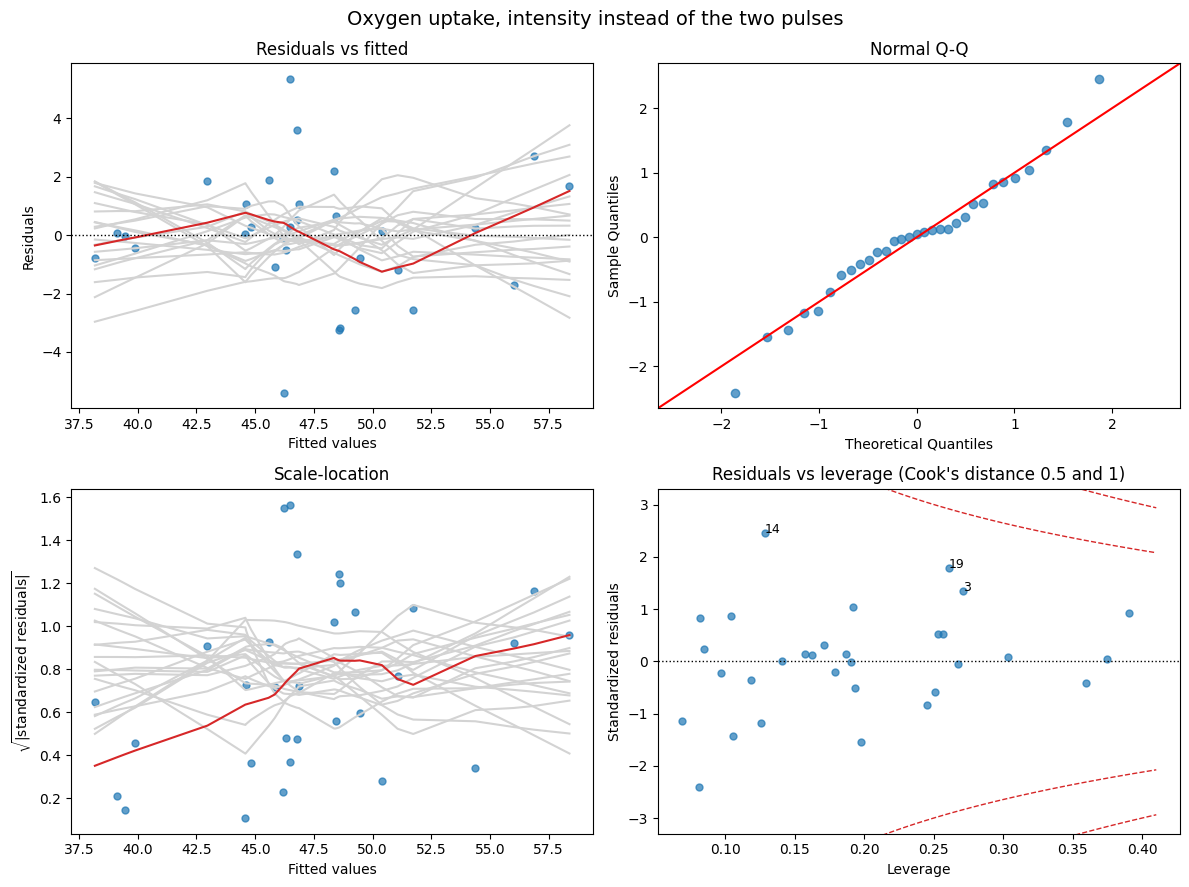

In [6]:
fitness["intensity"] = fitness["runpulse"] / fitness["maxpulse"]
combined = smf.ols("oxy ~ age + weight + runtime + rstpulse + intensity", data=fitness).fit()
print(vif_table(fitness[["age", "weight", "runtime", "rstpulse", "intensity"]]).to_dict())
print(f"R-squared: {combined.rsquared:.3f}")
diagnostic_plots(combined, title="Oxygen uptake, intensity instead of the two pulses")

Both remedies remove the multicollinearity (all VIFs close to 1). The intensity model keeps more of the explained variance ($R^2$ 0.839 vs 0.818) because it does not throw away the information in `maxpulse`. Its residual plots look as good as those of the full model.

### Which predictors are really needed?

Starting from the empty model, forward selection adds at each step the predictor that lowers the AIC the most:

In [7]:
selected = forward_selection(fitness, "oxy", ["age", "weight", "runtime", "rstpulse", "intensity"], criterion="aic")
final = smf.ols("oxy ~ " + " + ".join(selected), data=fitness).fit()
print()
print(final.summary().tables[1])
print(f"R-squared: {final.rsquared:.3f}")

add  runtime                  AIC 192.67 -> 152.51
add  intensity                AIC 152.51 -> 145.86
add  age                      AIC 145.86 -> 144.72
add  weight                   AIC 144.72 -> 144.31

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    156.3786     20.385      7.671      0.000     114.476     198.281
runtime       -2.7842      0.333     -8.353      0.000      -3.469      -2.099
intensity    -66.7561     20.397     -3.273      0.003    -108.684     -24.828
age           -0.1754      0.085     -2.055      0.050      -0.351    6.66e-05
weight        -0.0776      0.053     -1.451      0.159      -0.188       0.032
R-squared: 0.838


In [8]:
sm.stats.anova_lm(final, combined)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,26.0,138.184286,0.0,NaN,NaN,NaN
1,25.0,136.849382,1.0,1.334904,0.243864,0.62574


Running time is by far the most informative variable, followed by intensity and age; weight brings only a marginal AIC improvement, and resting pulse is not selected. The partial F-test confirms that dropping `rstpulse` does not lose significant information (p = 0.63).

The final model explains about 84% of the variance of oxygen uptake with four measurements that require no lab: a stopwatch, a heart rate monitor, age and weight. Whether this precision is enough depends on the application: it is plenty for a fitness assessment, probably not for a clinical diagnosis.

## 2. Hospital length of stay

The second dataset describes 113 hospitals. We want to explain the average length of stay of patients (`length`, in days) using:

- `age`: average age of patients;
- `infection`: average risk of a hospital infection (%);
- `region`: NE, N, S or W;
- `beds`, `pat`, `nurs`: number of beds, average daily number of patients, number of nurses.

In [9]:
senic = pd.read_csv("data/senic.csv").rename(columns={"inf": "infection"})
size_vars = ["beds", "pat", "nurs"]
print(senic[size_vars].corr().round(2))
vif_table(senic[["age", "infection"] + size_vars])

      beds   pat  nurs
beds  1.00  0.98  0.92
pat   0.98  1.00  0.91
nurs  0.92  0.91  1.00


age           1.01
infection     1.22
beds         29.76
pat          27.54
nurs          6.48
Name: VIF, dtype: float64

`beds`, `pat` and `nurs` are almost perfectly correlated, with VIFs up to 30: they all measure the **size** of the hospital. Keeping all three would make their coefficients meaningless.

Instead of dropping two of them, we keep the size information once (the number of patients) and turn the other two into ratios that describe *how* the hospital works:

- `pat_per_bed`: bed occupancy;
- `pat_per_nurse`: workload of the nursing staff.

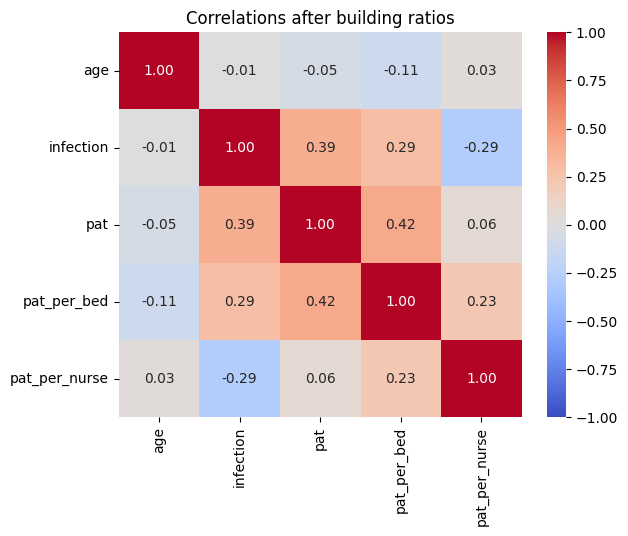

age              1.02
infection        1.42
pat              1.35
pat_per_bed      1.38
pat_per_nurse    1.25
Name: VIF, dtype: float64

In [10]:
senic["pat_per_bed"] = senic["pat"] / senic["beds"]
senic["pat_per_nurse"] = senic["pat"] / senic["nurs"]
new_vars = ["age", "infection", "pat", "pat_per_bed", "pat_per_nurse"]

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(senic[new_vars].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlations after building ratios")
plt.show()
vif_table(senic[new_vars])

The correlations are now low and all VIFs are close to 1, while no information has been discarded.

The length of stay, the number of patients and the patients per nurse are positive and right-skewed, so we model them on the log scale (patients per bed is a share between 0 and 1 and stays as it is):

In [11]:
terms = ["age", "infection", "C(region)", "np.log(pat)", "pat_per_bed", "np.log(pat_per_nurse)"]
hospital_full = smf.ols("np.log(length) ~ " + " + ".join(terms), data=senic).fit()
print(f"R-squared: {hospital_full.rsquared:.3f}")
sm.stats.anova_lm(hospital_full, typ=2).round(4)

R-squared: 0.608


,sum_sq,df,F,PR(>F)
C(region),0.4106,3.0,10.2391,0.0000
age,0.1201,1.0,8.9809,0.0034
infection,0.3654,1.0,27.3372,0.0000
np.log(pat),0.0934,1.0,6.9861,0.0095
pat_per_bed,0.0098,1.0,0.7326,0.3940
np.log(pat_per_nurse),0.0527,1.0,3.9392,0.0498
Residual,1.3903,104.0,NaN,NaN


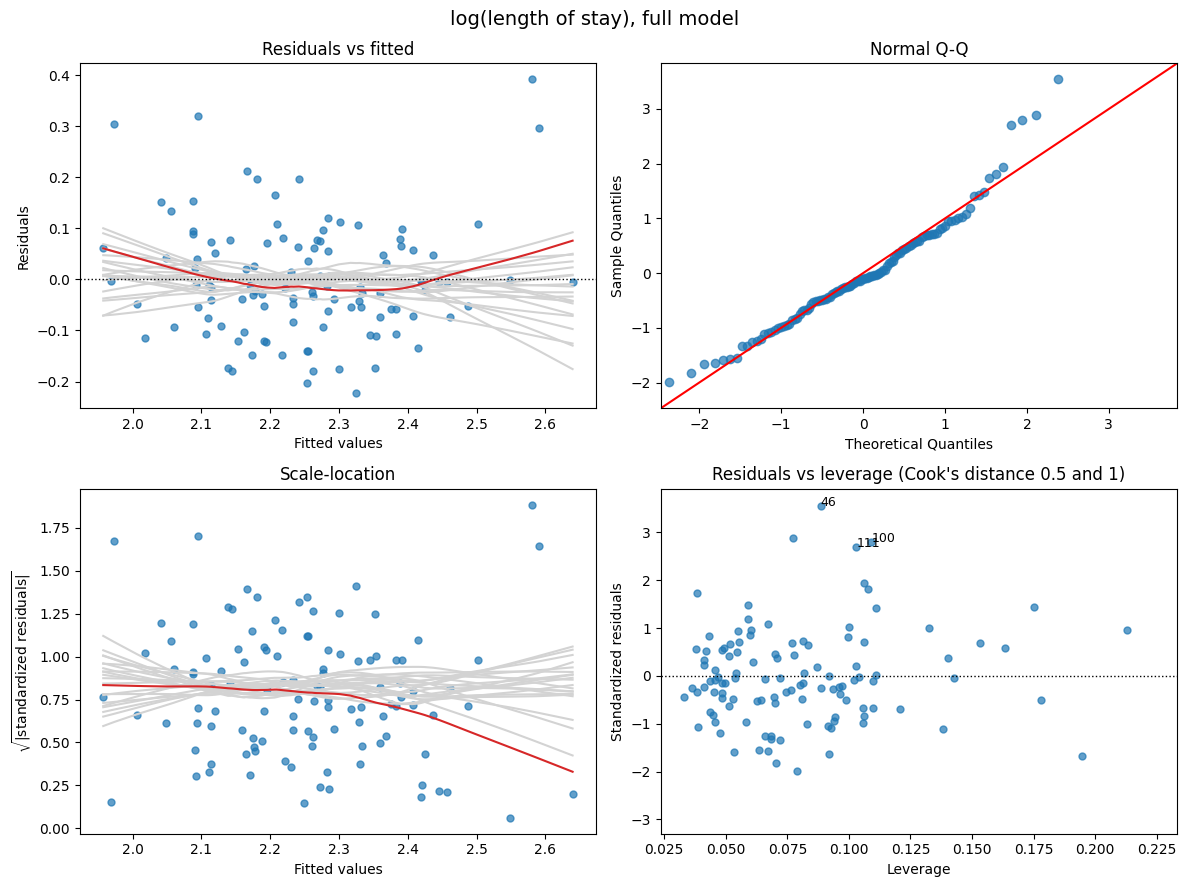

In [12]:
diagnostic_plots(hospital_full, title="log(length of stay), full model")

The residual plots support the assumptions of linearity and constant variance. The Q-Q plot shows somewhat heavy tails: a few hospitals (46, 42, 100) have unusually long or short stays, but their Cook's distances are small, so they do not drive the fit.

All terms are significant except bed occupancy (p = 0.39). Backward elimination with BIC, which penalises model size more than AIC, reaches the same conclusion:

In [13]:
selected = backward_selection(senic, "np.log(length)", terms, criterion="bic")
hospital_final = smf.ols("np.log(length) ~ " + " + ".join(selected), data=senic).fit()
print()
print(hospital_final.summary().tables[1])

drop pat_per_bed              BIC -133.74 -> -137.67

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.3609      0.158      8.587      0.000       1.047       1.675
C(region)[T.NE]           0.0781      0.031      2.540      0.013       0.017       0.139
C(region)[T.S]           -0.0454      0.029     -1.580      0.117      -0.102       0.012
C(region)[T.W]           -0.1316      0.038     -3.490      0.001      -0.206      -0.057
age                       0.0074      0.003      2.924      0.004       0.002       0.012
infection                 0.0554      0.010      5.449      0.000       0.035       0.076
np.log(pat)               0.0526      0.017      3.182      0.002       0.020       0.085
np.log(pat_per_nurse)     0.0820      0.036      2.283      0.024       0.011       0.153


In [14]:
sm.stats.anova_lm(hospital_final, hospital_full)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,105.0,1.400044,0.0,NaN,NaN,NaN
1,104.0,1.390252,1.0,0.009793,0.732567,0.39402


The final model drops bed occupancy and keeps everything else. Since the response is on the log scale, the coefficients are approximately relative effects:

- each additional percentage point of **infection risk** lengthens the stay by about 6%;
- older patients stay longer (about 0.7% per year of average age);
- **larger hospitals** (more patients) and hospitals where each nurse looks after more patients have longer stays;
- hospitals in the **North-East** have the longest stays, those in the **West** the shortest.

The partial F-test confirms that removing bed occupancy costs nothing (p = 0.39, the same p-value as its t-test in the full model, as it must be when a single term is removed).

## 3. Fund of hedge funds: recovering a portfolio

A *fund of hedge funds* (FoHF) invests in other hedge funds following different strategies. The dataset contains 96 monthly returns of a FoHF and of 12 hedge fund sub-indices, one per strategy (relative value, convertible arbitrage, fixed income arbitrage, equity market neutral, event driven, distressed securities, merger arbitrage, long/short equity, global macro, emerging markets, CTA/managed futures, short selling).

The FoHF does not publish its allocation. If it invests in some of these strategies, its return should be approximately a linear combination of the corresponding sub-indices. Can we find out which ones?

In [15]:
fohf = pd.read_csv("data/FoHF.csv")
strategies = [c for c in fohf.columns if c != "FoHF"]
fohf_full = smf.ols("FoHF ~ " + " + ".join(strategies), data=fohf).fit()
print(f"R-squared: {fohf_full.rsquared:.3f}   global F-test p-value: {fohf_full.f_pvalue:.1e}")
print(fohf_full.pvalues.drop("Intercept").round(3).sort_values().to_string())

R-squared: 0.808   global F-test p-value: 1.0e-24
FIA    0.000
CTA    0.000
CA     0.025
RV     0.026
LSE    0.127
GM     0.147
ED     0.148
EM     0.164
SS     0.167
EMN    0.352
MA     0.867
DS     0.951


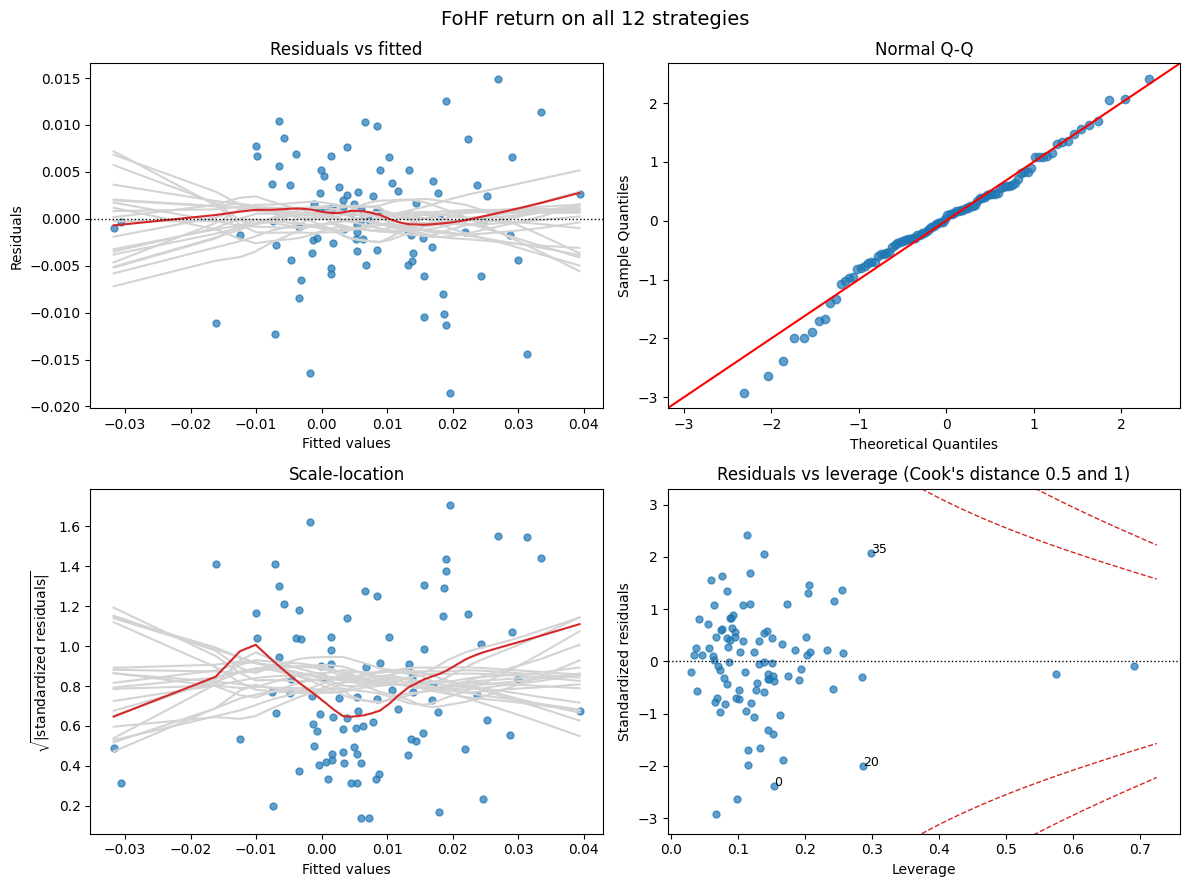

In [16]:
diagnostic_plots(fohf_full, title="FoHF return on all 12 strategies")

The sub-indices explain about 81% of the variance of the fund's return, but only four strategies are significant at the 5% level. The residual plots are acceptable. Financial returns often have time-varying volatility, and the scale-location smoother does move a bit, but not enough to be a concern. Two months have high leverage but small Cook's distance.

Are some strategies redundant?

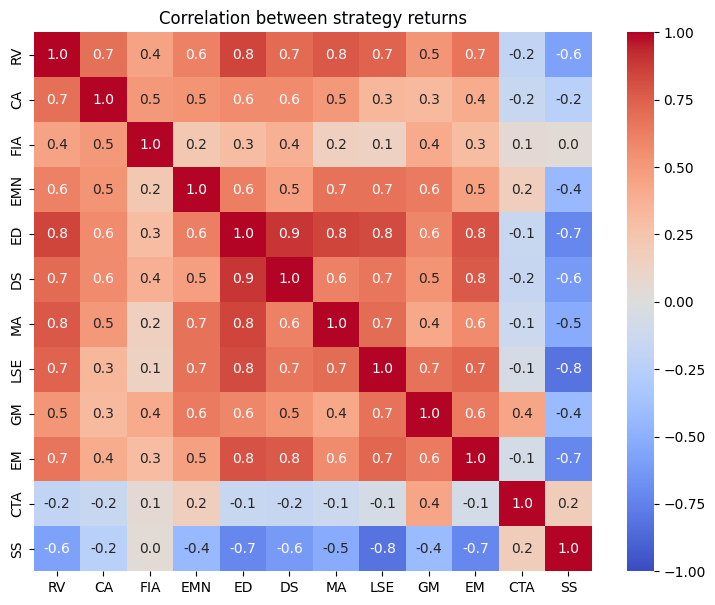

ED     29.97
LSE    10.05
DS      9.40
MA      8.00
RV      6.39
GM      5.70
SS      4.97
EM      4.26
EMN     3.67
CA      2.98
FIA     2.27
CTA     2.23
Name: VIF, dtype: float64

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(fohf[strategies].corr(), annot=True, fmt=".1f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation between strategy returns")
plt.show()
vif_table(fohf[strategies]).sort_values(ascending=False)

Event driven (`ED`, VIF ≈ 30) and long/short equity (`LSE`, VIF ≈ 10) are critically collinear, and several other strategies are close to the threshold: many hedge fund strategies react to the same market movements.

Here the usual remedies do not apply. We cannot combine sub-indices into new variables or transform them, because the fund's return is literally a weighted sum of the strategies it holds. What we can do is assume the fund holds only *some* of the strategies and use variable selection to find out which. We run both backward and forward selection with BIC:

In [18]:
print("Backward elimination:")
backward = backward_selection(fohf, "FoHF", strategies, criterion="bic")
print("\nForward selection:")
forward = forward_selection(fohf, "FoHF", strategies, criterion="bic")
print(f"\nSame strategies selected: {sorted(backward) == sorted(forward)}")

Backward elimination:
drop DS                       BIC -647.25 -> -651.81
drop MA                       BIC -651.81 -> -656.34


drop EMN                      BIC -656.34 -> -659.86
drop EM                       BIC -659.86 -> -662.47
drop SS                       BIC -662.47 -> -665.65
drop LSE                      BIC -665.65 -> -667.91
drop RV                       BIC -667.91 -> -668.34

Forward selection:
add  GM                       BIC -543.80 -> -633.85
add  CA                       BIC -633.85 -> -649.97


add  FIA                      BIC -649.97 -> -654.30
add  CTA                      BIC -654.30 -> -657.04
add  ED                       BIC -657.04 -> -668.34

Same strategies selected: True


In [19]:
fohf_final = smf.ols("FoHF ~ " + " + ".join(sorted(backward)), data=fohf).fit()
print(fohf_final.summary().tables[1])
print(f"R-squared: {fohf_final.rsquared:.3f}")
print(f"Sum of the estimated weights: {fohf_final.params.drop('Intercept').sum():.2f}")
print("\nVIF of the selected strategies:", vif_table(fohf[sorted(backward)]).to_dict())
print()
print(sm.stats.anova_lm(fohf_final, fohf_full))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0019      0.001     -2.043      0.044      -0.004   -5.11e-05
CA             0.1757      0.084      2.099      0.039       0.009       0.342
CTA            0.1535      0.034      4.479      0.000       0.085       0.222
ED             0.2654      0.066      4.021      0.000       0.134       0.397
FIA            0.2985      0.073      4.063      0.000       0.153       0.444
GM             0.2469      0.064      3.855      0.000       0.120       0.374
R-squared: 0.785
Sum of the estimated weights: 1.14

VIF of the selected strategies: {'CA': 1.85, 'CTA': 1.82, 'ED': 2.72, 'FIA': 1.54, 'GM': 3.0}

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0      90.0  0.004003      0.0       NaN       NaN       NaN
1      83.0  0.003575      7.0  0.000428  1.419443  0.208521


Both directions agree on the same five strategies: **convertible arbitrage, fixed income arbitrage, event driven, global macro and CTA**. Together they explain almost as much as all twelve ($R^2$ 0.785 vs 0.808), and the partial F-test confirms that the other seven add nothing significant (p = 0.21). The multicollinearity has disappeared (all VIFs below 3).

The coefficients can be read as **portfolio weights**: the fund appears to allocate roughly 15–30% to each of these five strategies. The weights sum to slightly more than 1, which is consistent with a moderate use of leverage. The small but significant negative intercept (about −0.2% per month) means the fund earns slightly less than the strategies it holds, which is what we would expect from the extra layer of fees a fund of funds charges.

## Summary

- Multicollinearity inflates standard errors and makes individual coefficients unreliable. **VIFs** quantify it for every predictor.
- Remedies depend on the problem: **drop** a redundant variable, **combine** correlated variables into a meaningful new one (a ratio, an intensity), or **select** a subset when the variables cannot be changed.
- **Stepwise selection** with AIC or BIC, checked with **partial F-tests**, gives compact models that keep almost all of the explanatory power.
- Building good variables (intensity, occupancy, workload) is often more valuable than any automatic procedure: it removes the redundancy and gives coefficients a clear interpretation.